# alchemy-viz gallery

Every view alchemy-viz draws today, as a picture.

> ### This notebook is for viewing on GitHub. It is not the one you run.
>
> **The outputs below are screenshots**, not live views. They exist because
> GitHub's notebook renderer strips `<iframe>` and `<script>` from cell outputs,
> which is everything `view()` emits - so an executed copy of the demo
> notebook shows a blank under every cell there. `image/png` is the one output
> type that survives.
>
> **You can run this one too.** Its cells hold the real `view()` call, so
> running it replaces each screenshot with the live, interactive view - a good
> way to check that a picture is honest. Just do not commit the result: that
> strips out the pictures this file exists to carry. `pixi run gallery`
> regenerates them, and is what to run whenever you change what a view draws.
> [`README.md`](./README.md) is the full note.

**Using OpenFE?** These pictures are of committed example payloads, which is not
how you will call this. Your own objects go in directly - `view(network)`,
`view(campaign)` - because openfe re-exports gufe's classes rather than defining
its own, so there is no conversion step.
[`docs/openfe.md`](../../docs/openfe.md) is that path: the `network_setup/`
directory `openfe plan-rbfe-network` writes, the same campaign planned in Python,
and where `view()` goes in the sequence. [`docs/cli.md`](../../docs/cli.md) is the
shell equivalent, which needs no notebook at all.

The interactive version of this file is
[`alchemy-viz-demo.ipynb`](./alchemy-viz-demo.ipynb), ten cells on what a notebook
cell gets:

```
pixi run notebook     # JupyterLab
pixi run marimo       # the same notebook, in marimo
```

Every payload type the schema declares is drawn, so what follows is the whole of
what alchemy-viz can show. Where two types share an element - the three PDB kinds,
the mapping standalone and inside a network - both are here, because sharing a
drawing path is a claim that has to be checked by looking.


In [1]:
import json
from pathlib import Path

from alchemy_viz import view

EXAMPLES = Path("../")
payloads = {p.stem: json.loads(p.read_text()) for p in sorted(EXAMPLES.glob("*.json"))}

### `small_molecule.json` - `SmallMoleculeComponentViz`

2D RDKit depiction beside the 3D conformer, with SMILES, charge and atom counts.

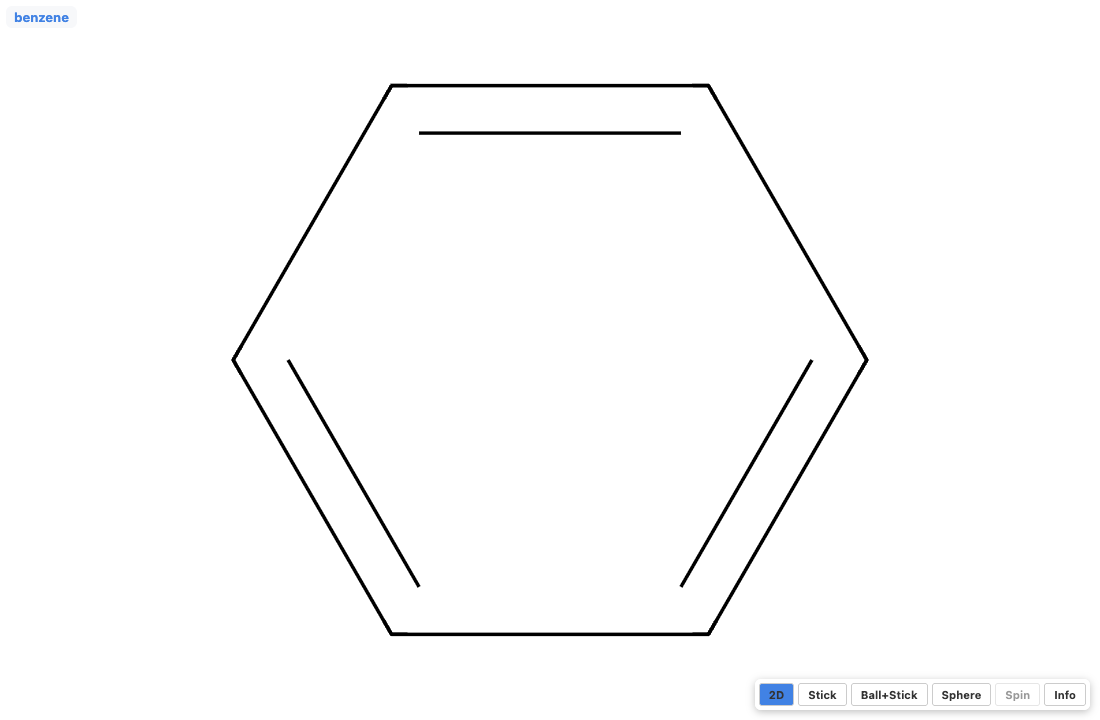

In [1]:
view(payloads["small_molecule"])

### `small_molecule_charged.json` - `SmallMoleculeComponentViz`

The same view, with a non-zero formal charge.

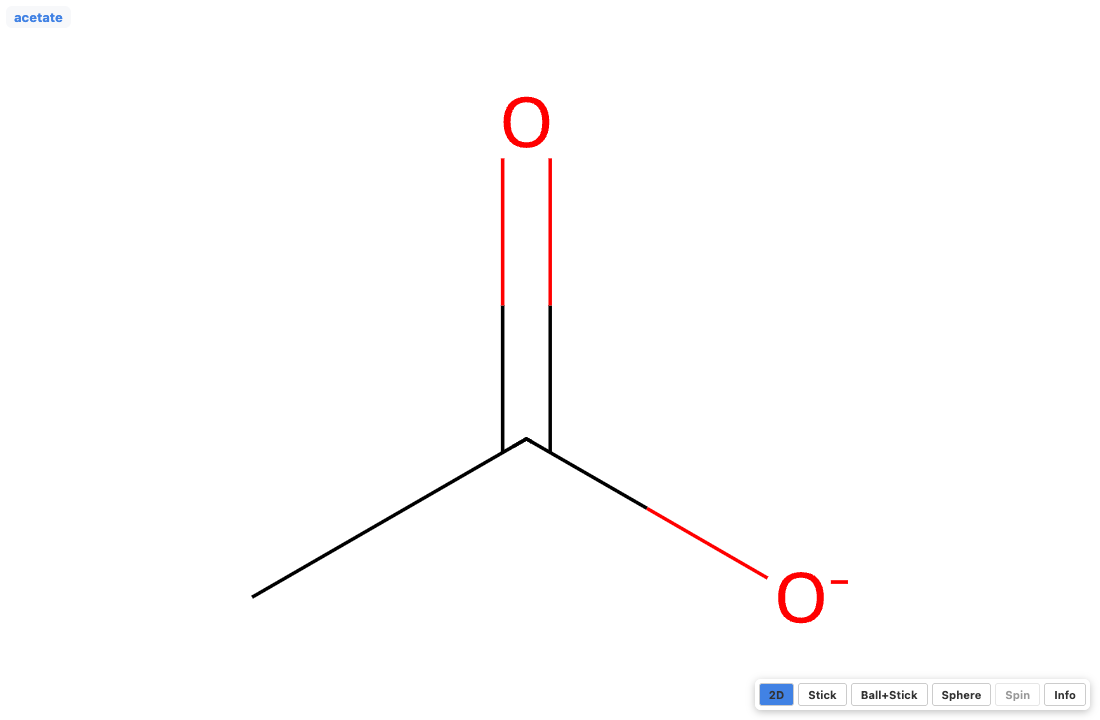

In [1]:
view(payloads["small_molecule_charged"])

### `protein.json` - `ProteinComponentViz`

3Dmol with representation and colour-scheme switchers; waters hidden by default.

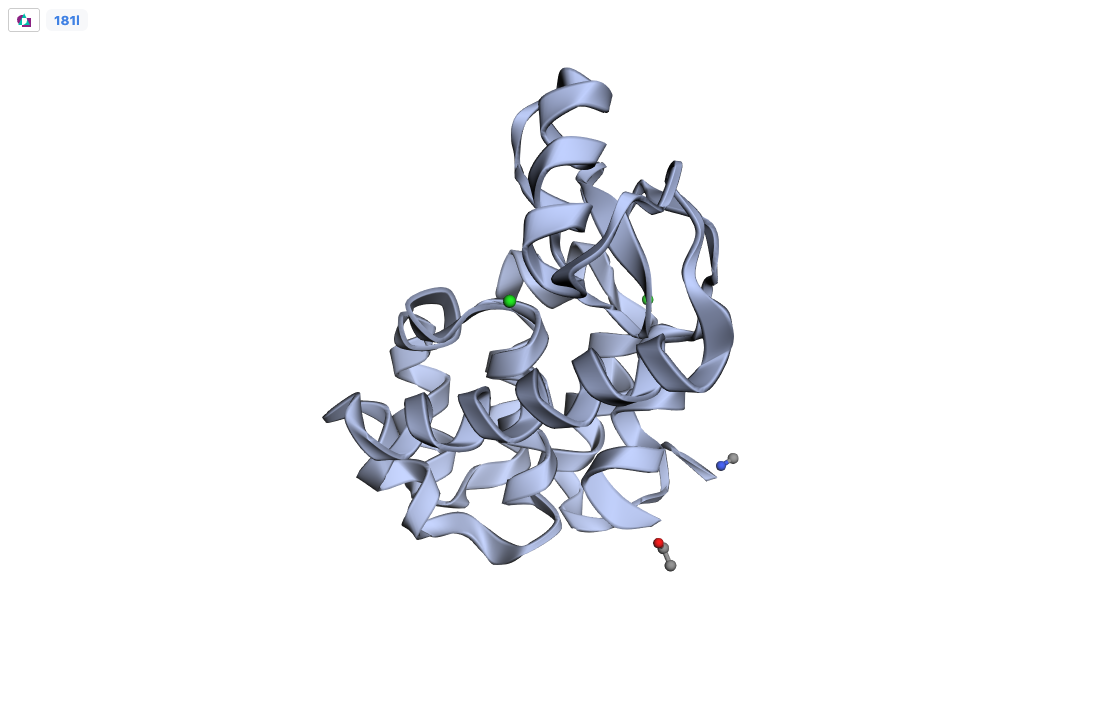

In [1]:
view(payloads["protein"])

### `protein_fragment.json` - `ProteinComponentViz`

A small protein, so the 3D view loads fast while iterating.

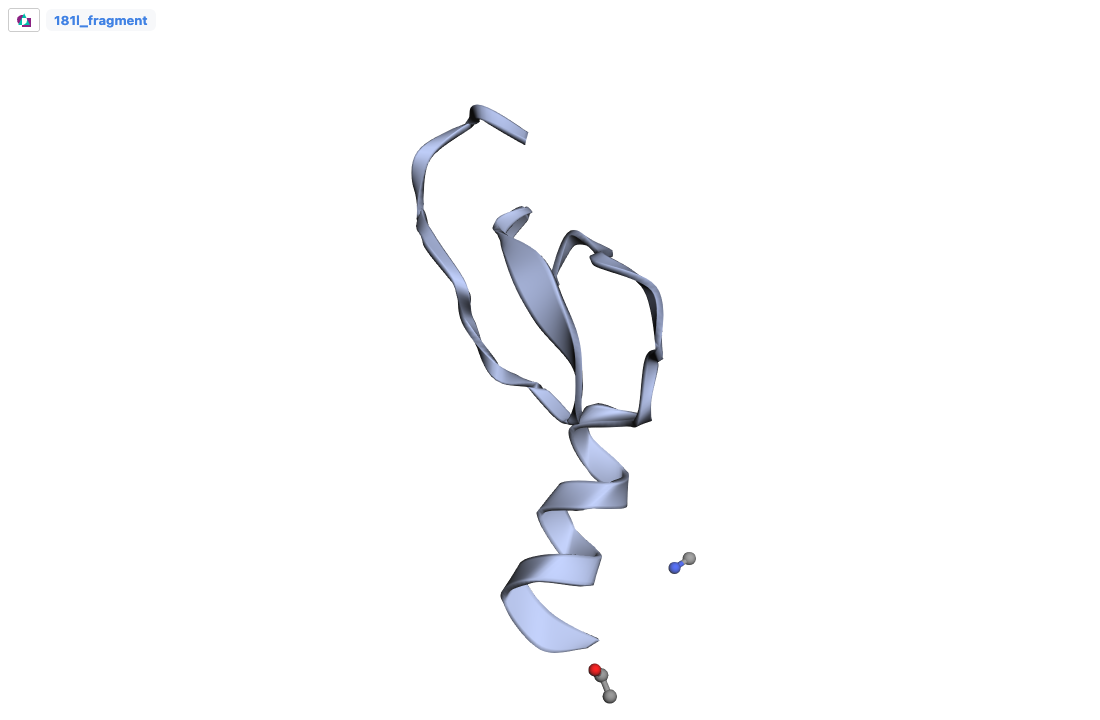

In [1]:
view(payloads["protein_fragment"])

### `protein_membrane.json` - `ProteinMembraneComponentViz`

The same element, reached the other way. Python's MRO walk gives a membrane system the protein *builder*, but the payload it emits says `ProteinMembraneComponentViz`, and that type needs its own entry in the browser's dispatch table - inheritance on one side of the contract is not inheritance on the other, so both sides say it separately.

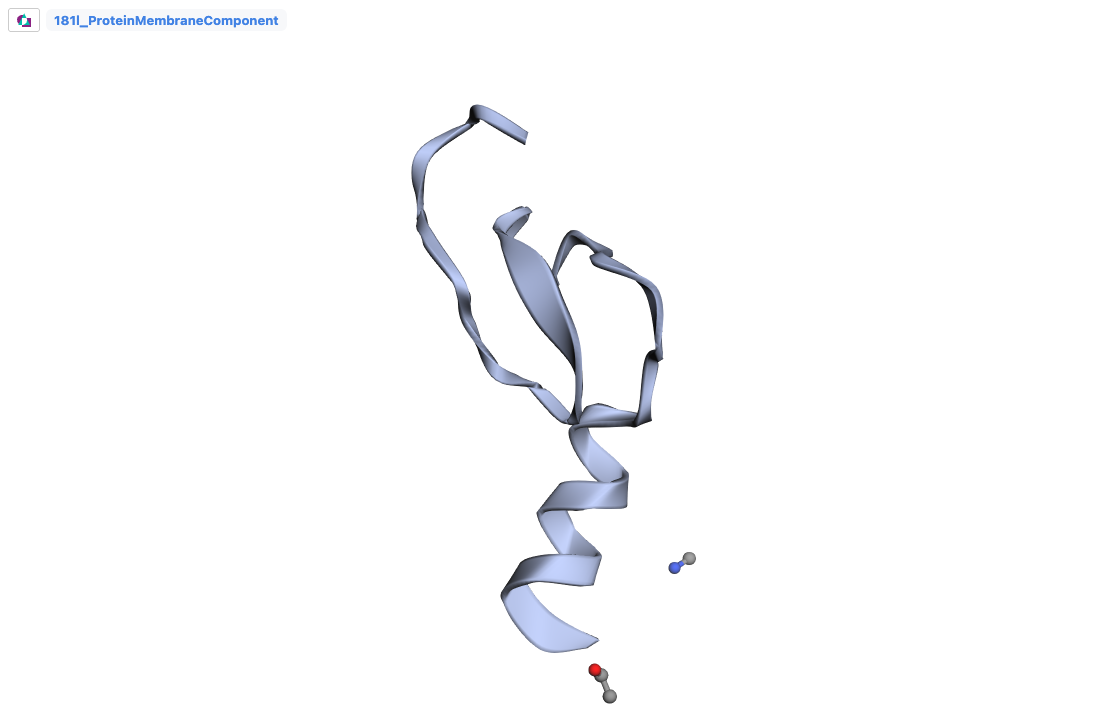

In [1]:
view(payloads["protein_membrane"])

### `solvated_pdb.json` - `SolvatedPDBComponentViz`

`SolvatedPDBComponentViz`, dispatched to the same element for the same reason.

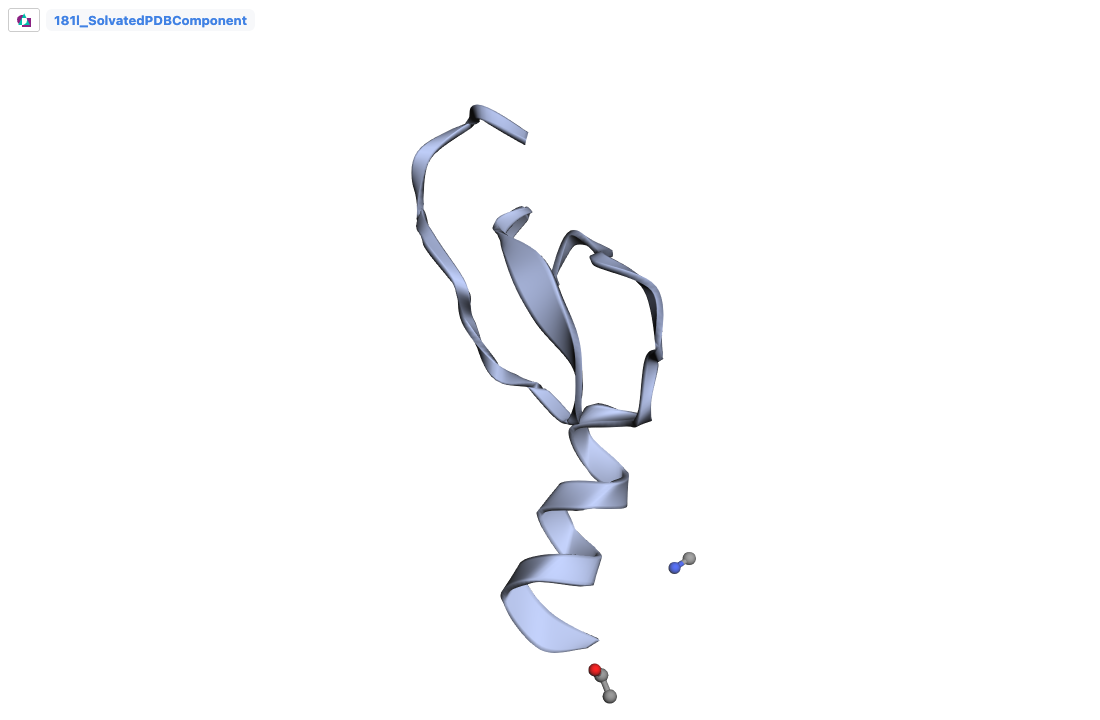

In [1]:
view(payloads["solvated_pdb"])

### `ligand_network.json` - `LigandNetworkViz`

Radial graph of the ligands, with the selected edge's atom mapping on the right.

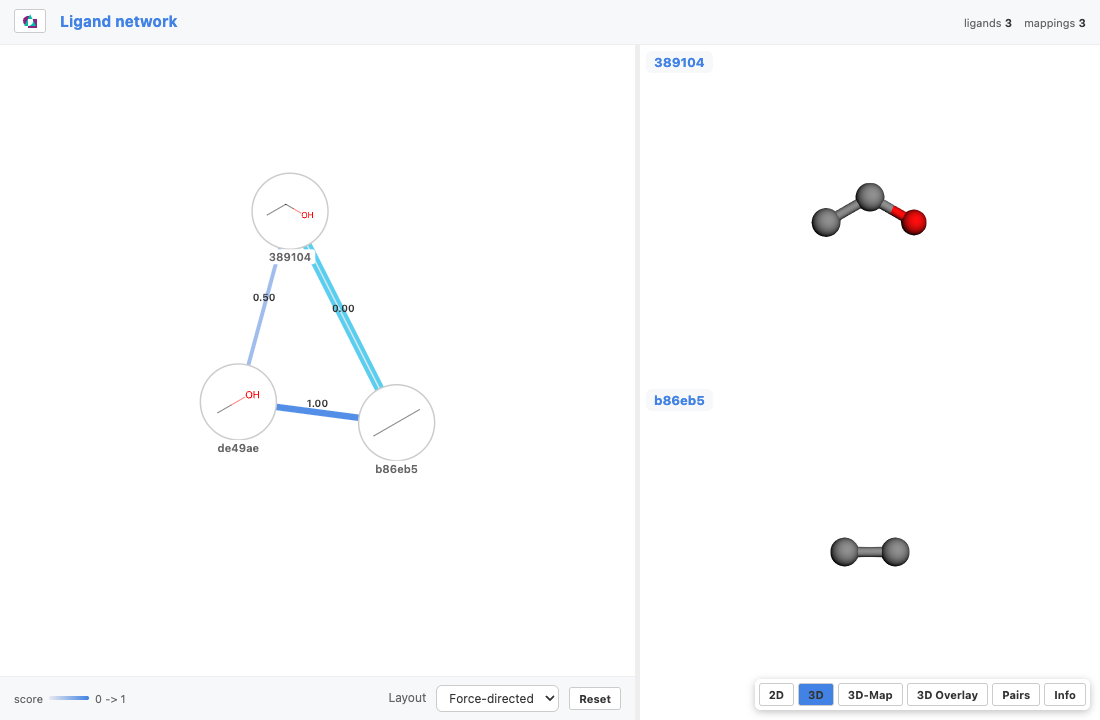

In [1]:
view(payloads["ligand_network"])

### `ligand_network_named.json` - `LigandNetworkViz`

The same network with the ligands named, so labels replace gufe keys.

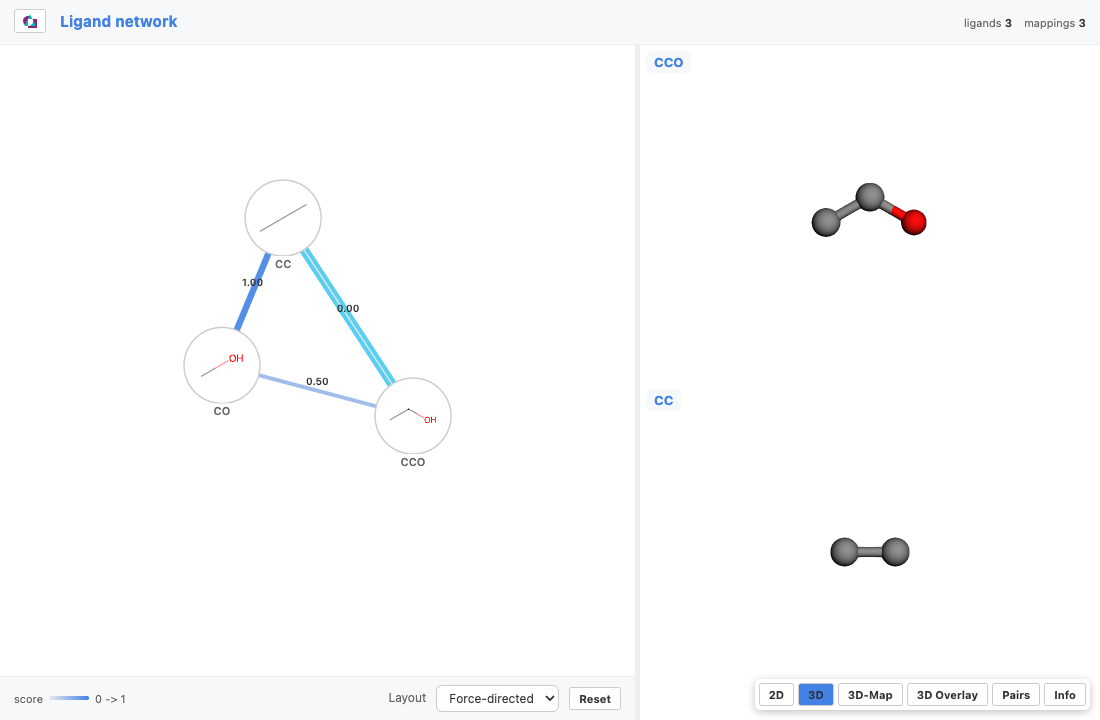

In [1]:
view(payloads["ligand_network_named"])

### `ligand_network_medium.json` - `LigandNetworkViz`

Ten TYK2 ligands and the nine mappings OpenFE's RBFE tutorial plans between them: a real network at the size a real network starts at, where the layout and the score colouring begin to carry information rather than decorate three nodes.

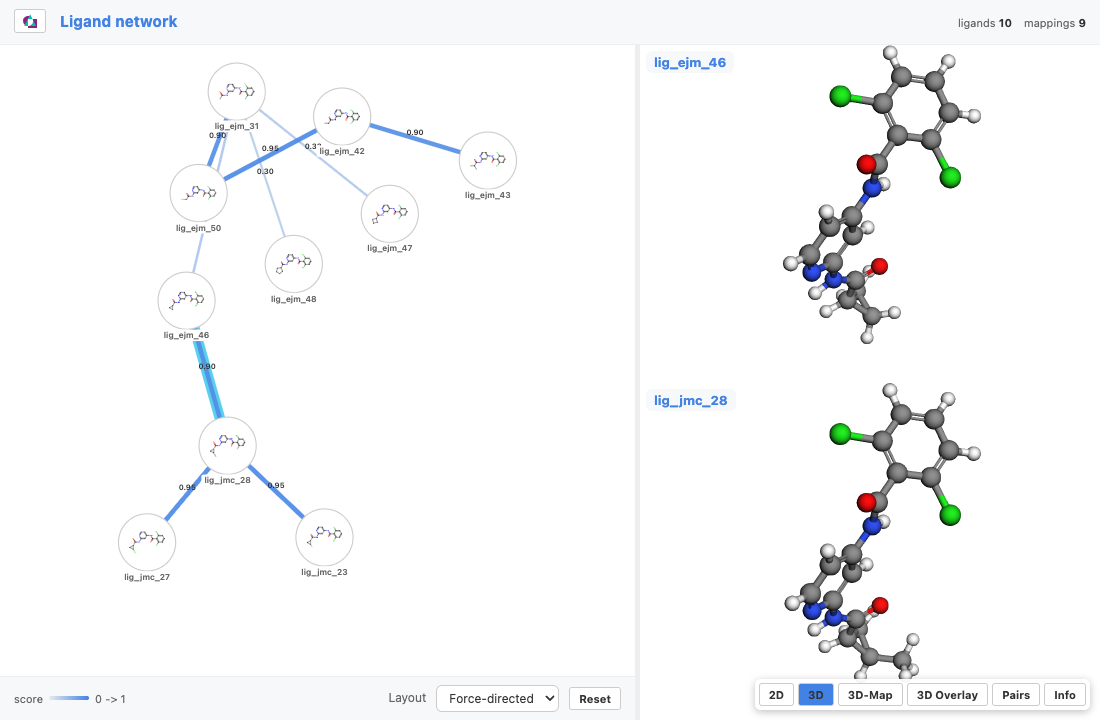

In [1]:
view(payloads["ligand_network_medium"])

### `ligand_network_charged.json` - `LigandNetworkViz`

Ten Eg5 ligands from OpenFE's published campaign, four neutral and six carrying a formal +1. The charge is badged on the nodes that have one and nowhere else, and the single mapping that changes it is dashed - which is what a real campaign looks like, since LOMAP plans around charge changes where it can.

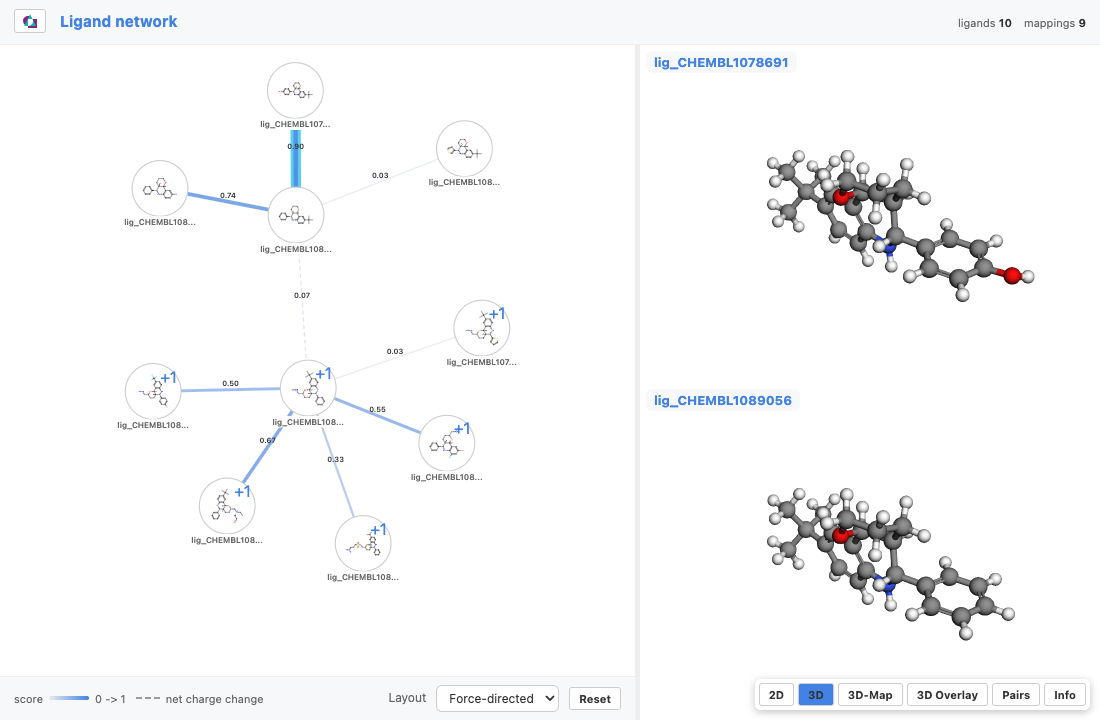

In [1]:
view(payloads["ligand_network_charged"])

### `ligand_network_large.json` - `LigandNetworkViz`

Two hundred ligands and 594 mappings, which is what the level-of-detail rule is for: depictions give way to dots and labels drop out as the graph gets denser, and zooming in brings them back. **The mappings are synthetic** - paired by atom index, scored by an arithmetic ramp - so this is a picture of the view under load, not of any chemistry.

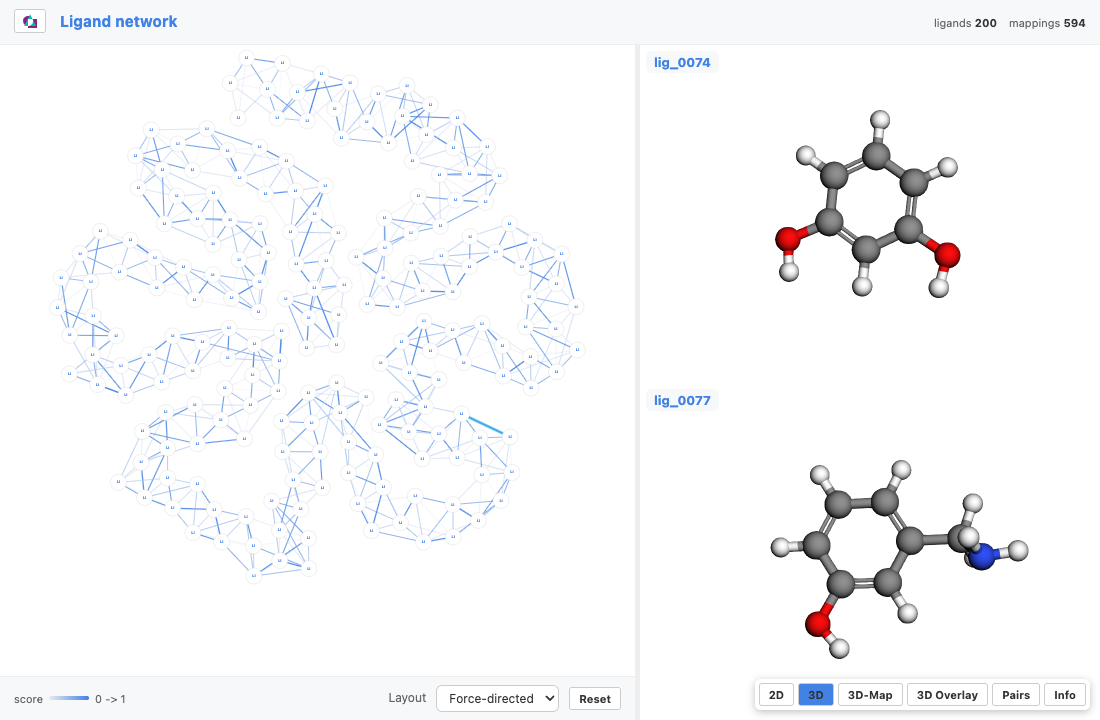

In [1]:
view(payloads["ligand_network_large"])

### `ligand_network_docked.json` - `LigandNetworkViz`

267 JAK2 inhibitors and 399 mappings: the same size as the load network above, and real. They were docked into one frame of a molecular dynamics trajectory with their shared aminopyrimidine core restrained, so unlike every other fixture here the ligands are superposed on each other - which is what `3D Overlay` in the detail pane is drawing when an edge is open. The **mappings are geometric**: atoms paired by where they sit in that frame, not planned by a mapper.

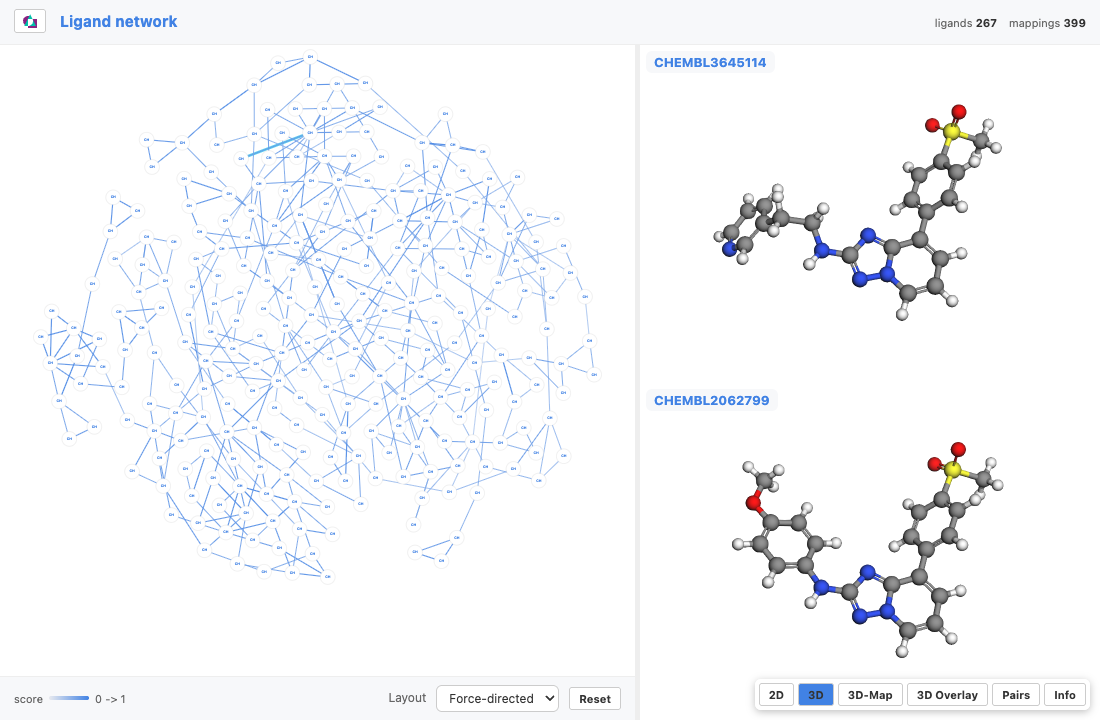

In [1]:
view(payloads["ligand_network_docked"])

### `ligand_atom_mapping.json` - `LigandAtomMappingViz`

One mapping on its own, in the same element the ligand network's detail pane mounts. Gufe's own first edge, ethanol to ethane: two atoms paired, which is the shape of a mapping and little else. All three mapping cards open on plain 3D - the correspondence itself is drawn by the other modes in the switcher, `3D-Map`, `Pairs` and `2D`.

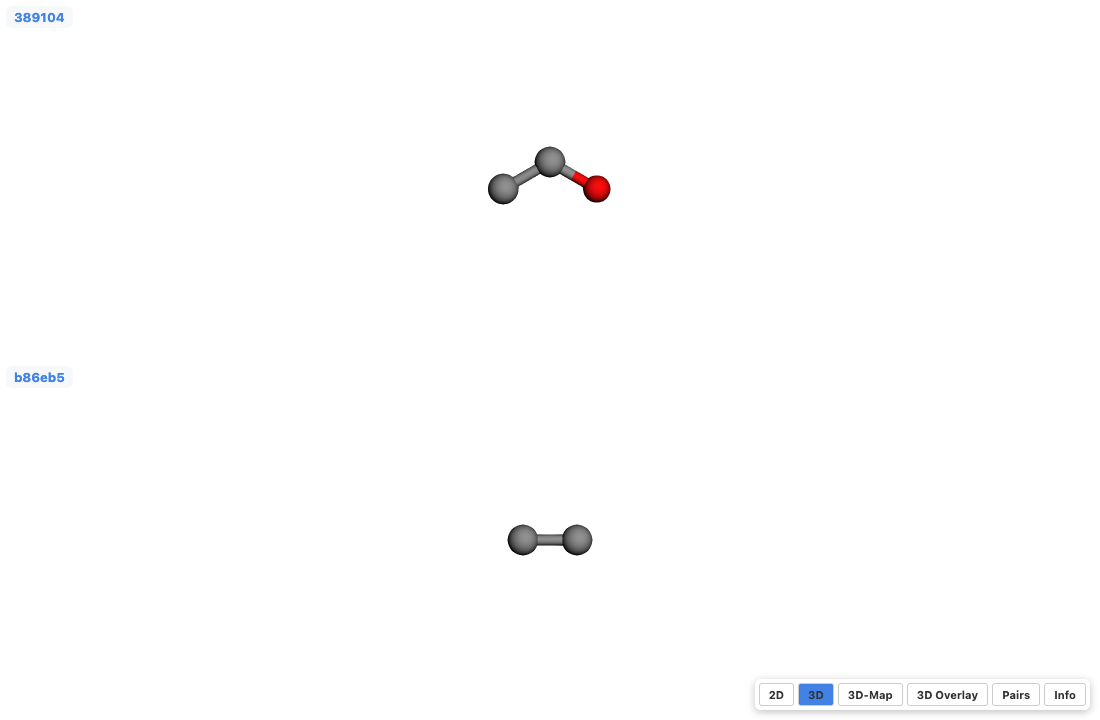

In [1]:
view(payloads["ligand_atom_mapping"])

### `ligand_atom_mapping_medium.json` - `LigandAtomMappingViz`

The same view on a real mapping, cut out of `ligand_network_medium`: the LOMAP-scored TYK2 edge that grows a methyl into a cyclopentyl. 28 of ligand A's 32 atoms map and 14 of ligand B's 42 do not, which is the difference `3D-Map` and `2D` colour - unique atoms against element changes, coloured the way gufe colours them.

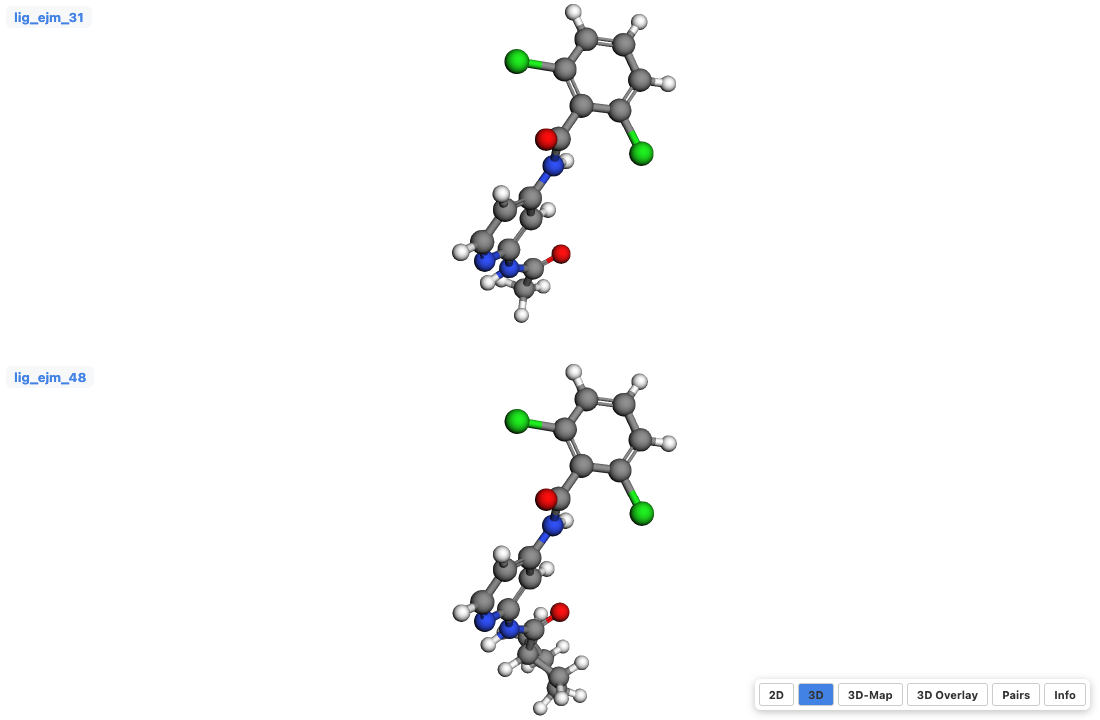

In [1]:
view(payloads["ligand_atom_mapping_medium"])

### `ligand_atom_mapping_large.json` - `LigandAtomMappingViz`

The largest pair in `ligand_network_large`, 36 atoms against 31 with all 31 paired. The load network's ligands are built from small scaffolds, so this is barely bigger than the TYK2 edge above - it is here for what it is rather than for its size. **The correspondence is synthetic**, paired by atom index like every edge of that network, so the modes that draw it are drawing nothing a chemist should read.

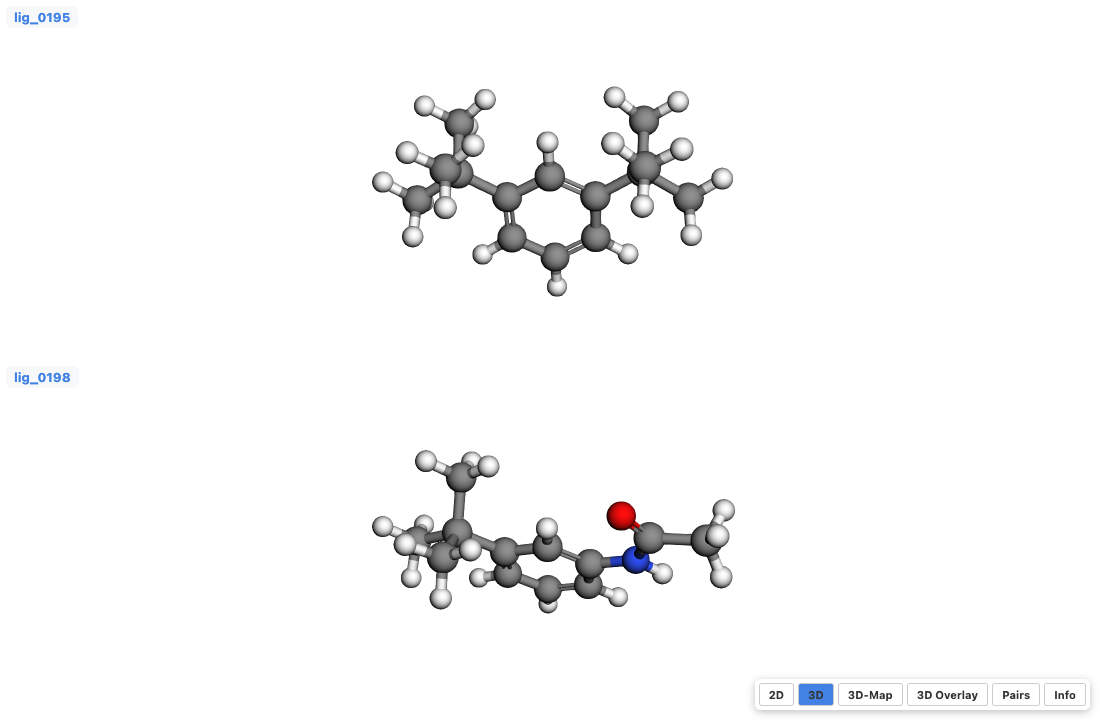

In [1]:
view(payloads["ligand_atom_mapping_large"])

### `alchemical_network_charged.json` - `AlchemicalNetworkViz`

The same Eg5 ligands as solvated transformations: the charge badge moves onto the boxes that carry a charged ligand, and both legs of the charge-changing mapping are dashed.

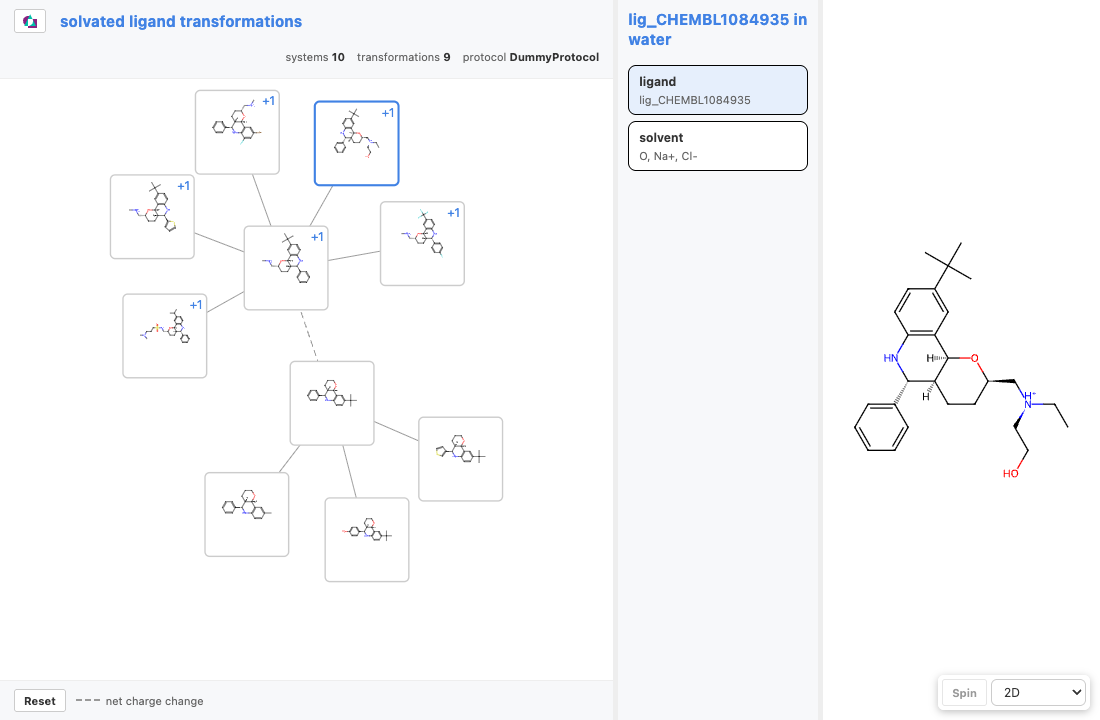

In [1]:
view(payloads["alchemical_network_charged"])

### `alchemical_network_medium.json` - `AlchemicalNetworkViz`

The same ten TYK2 ligands as a binding campaign: every mapping becomes two transformations, a solvent leg and a complex leg, so the graph is two components rather than one. The complex leg's systems each carry the TYK2 protein, which the registry holds once for all ten.

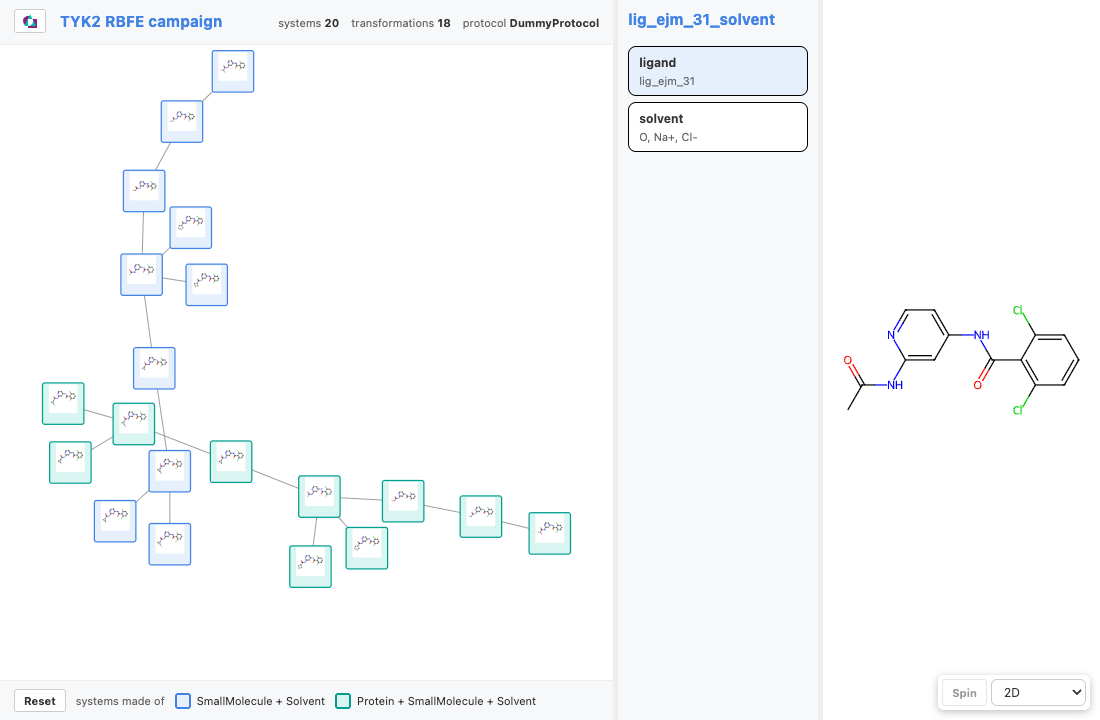

In [1]:
view(payloads["alchemical_network_medium"])

### `alchemical_network_large.json` - `AlchemicalNetworkViz`

The two-hundred-ligand graph one layer up from `ligand_network_large`, with the same 594 edges - the level-of-detail rule seen on the alchemical view at the size it was written for. **The mappings are synthetic**, as they are in the ligand view of the same graph.

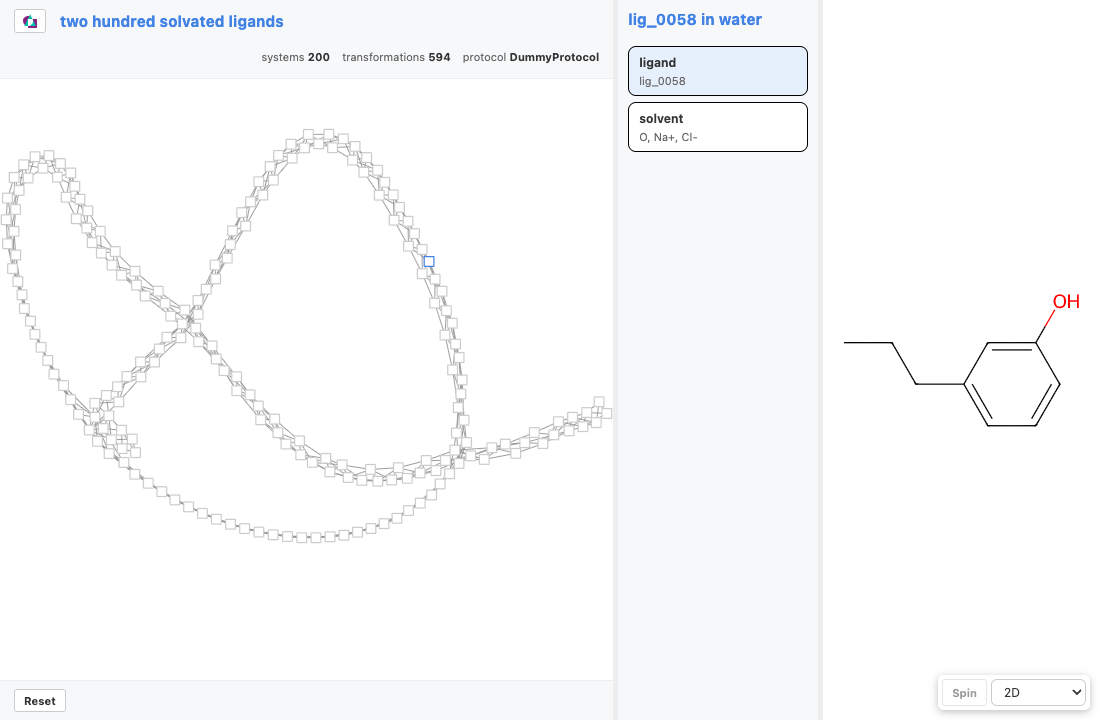

In [1]:
view(payloads["alchemical_network_large"])

### `alchemical_network_absolute.json` - `AlchemicalNetworkViz`

Absolute rather than relative: every transformation decouples one ligand from water, so none of them carries an atom mapping and they all end at the same reference state - a chemical system with no ligand in it, which is why the graph is a star. Clicking an edge shows the ligand it removes where a relative edge would show its mapping.

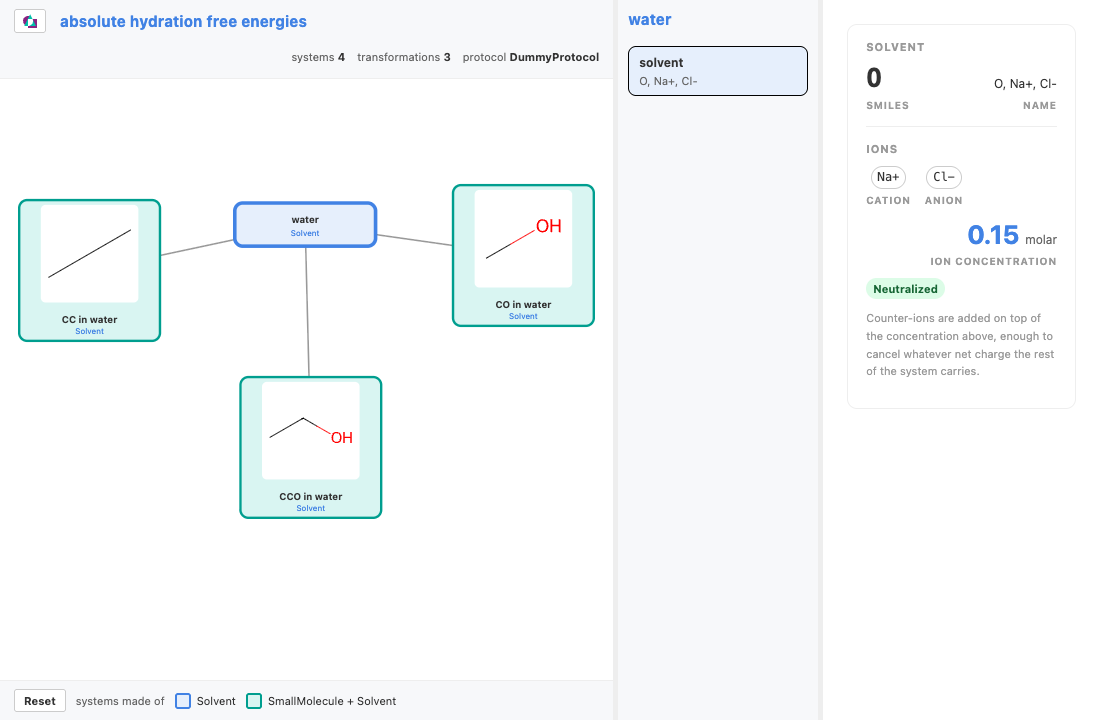

In [1]:
view(payloads["alchemical_network_absolute"])

### `alchemical_network_mixed.json` - `AlchemicalNetworkViz`

Both kinds in one campaign, which is what a planner produces when part of a series can be mapped onto itself and part of it cannot: four TYK2 mappings run in both legs, and two of the ligands are anchored by an absolute transformation into the apo protein. Three compositions rather than two, and the apo system is the one node with nothing drawn in it.

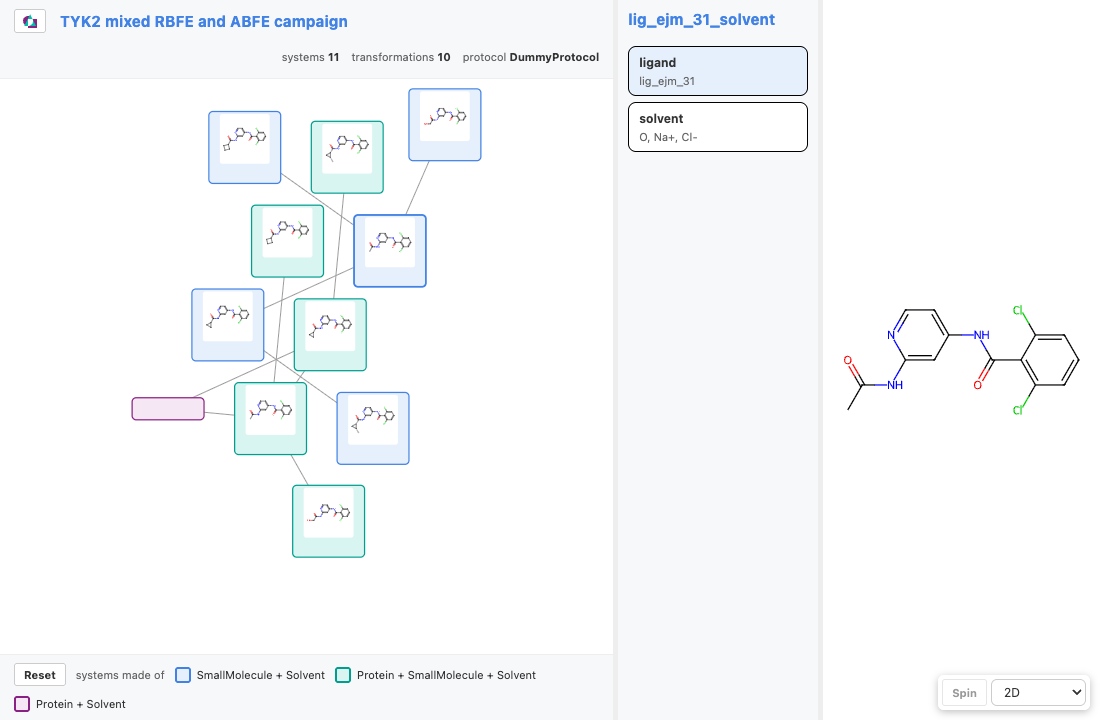

In [1]:
view(payloads["alchemical_network_mixed"])

### `chemical_system.json` - `ChemicalSystemViz`

The system's components down the left, the selected one drawn on the right in whichever view its own type gets - so a chemical system is a chooser over the views above rather than a picture of its own.

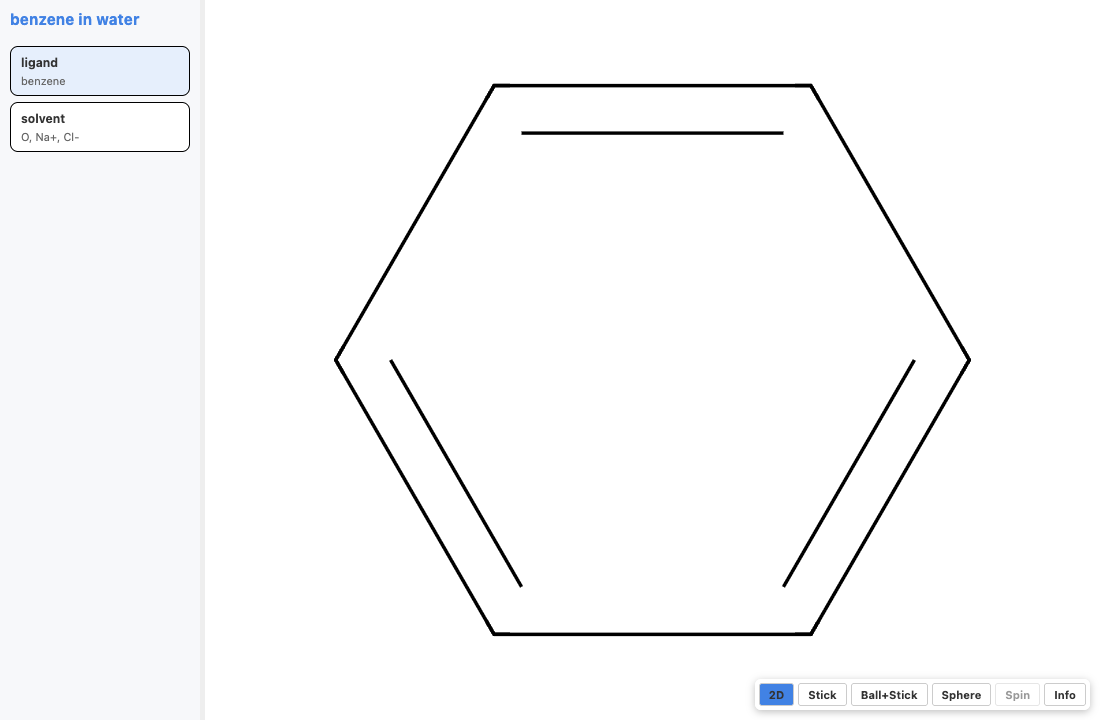

In [1]:
view(payloads["chemical_system"])

### `chemical_system_complex.json` - `ChemicalSystemViz`

The same chooser with one more thing to choose: a ligand and the protein it is bound to share a coordinate frame, so there is a picture of the two together that neither component has on its own. That pose is the point of a binding campaign, and drawing the components one at a time is the only way to lose it - hence `Complex` first in the strip, opening framed on the site rather than on the whole kinase.

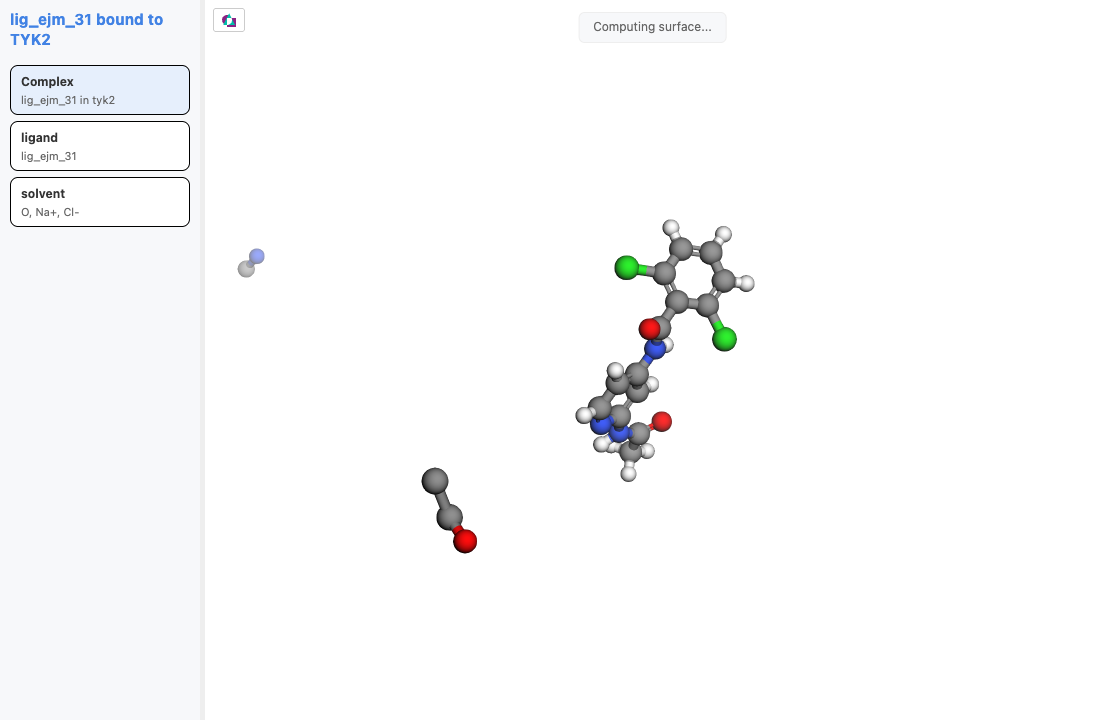

In [1]:
view(payloads["chemical_system_complex"])

### `chemical_system_ensemble.json` - `ChemicalSystemViz`

The `Complex` view with more than one ligand in it: six docked poses of the JAK2 series from `ligand_network_docked`, in the site they were docked into. They are the busiest ligand of that network and the five partners it overlaps best, so this is what an edge of that graph looks like in three dimensions. Nothing here arranges them - the poses and the kinase arrive in one frame and no coordinate is touched.

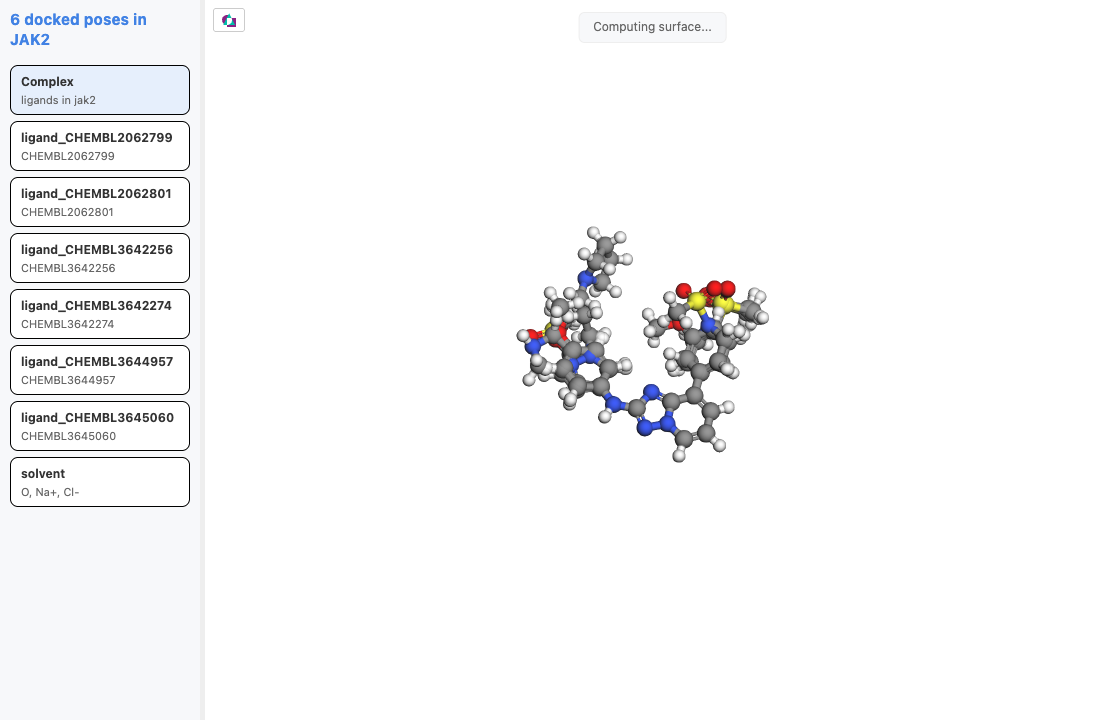

In [1]:
view(payloads["chemical_system_ensemble"])

### `solvent.json` - `SolventComponentViz`

A solvent component is a specification rather than a structure, so its view is a settings card beside a schematic that shows which ions are present - and says under itself, in words, that it is not showing how many.

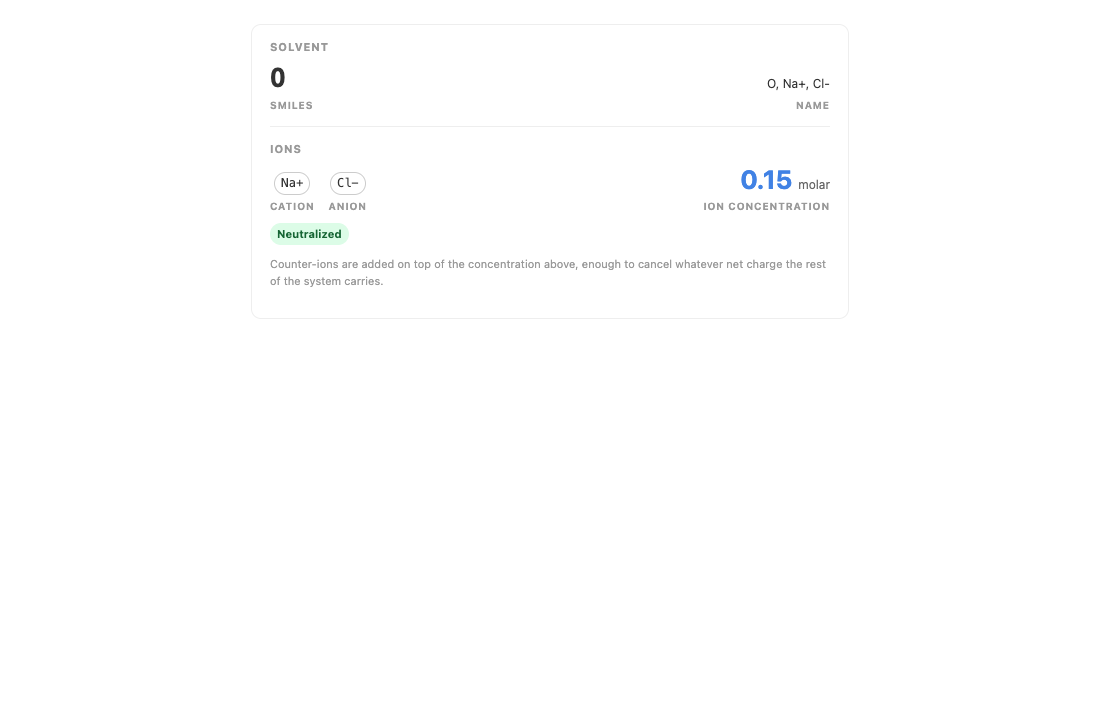

In [1]:
view(payloads["solvent"])